In [1]:
# ============================================================
# Image-Space vs Feature-Space SMOTE — Mechanism Ablation
#
# PURPOSE: Determine whether SMOTE recovery of dark-skin benign
#   accuracy operates via the geometric mechanism (synthesizing
#   in sparse embedding regions) or simply via data quantity
#   (more minority training examples regardless of space).
#
# HYPOTHESIS:
#   If the collapse is geometric in embedding space, feature-space
#   SMOTE should outperform image-space SMOTE — because pixel-space
#   interpolation produces blurry averages whose embeddings may not
#   fill the sparse region. If they match, the mechanism is
#   data-quantity-driven, not geometry-driven.
#
# THREE CONDITIONS (all frozen linear probe):
#   1. Baseline         — no augmentation
#   2. Feature SMOTE    — SMOTE in frozen embedding space (paper's method)
#   3. Image SMOTE      — SMOTE in pixel space, then feature extraction
#
# MODELS: CLIP ViT-L/14, ViT-B/16, ResNet-50, DINOv2-Base
# SEEDS:  42, 0, 1, 7, 99  (same as paper)
# SPLIT:  train FST I-II, test FST V-VI  (demographically-aware)
#
# DATASETS NEEDED:
#   - Fitzpatrick17k  (nazmusresan/fitzpatrick17k)
#
# OUTPUTS:
#   - Per-architecture × condition dark-skin benign accuracy (mean ± SD)
#   - Demo AUC per condition
#   - d_eff_norm of synthetic embeddings (both methods) — diagnostic
#   - PNG: 3-panel figure
#   - CSV: full per-seed results
#
# RUNTIME: ~3-4h on Kaggle T4 (dominated by 4 model × feature extraction)
# Kaggle: GPU T4, Internet ON
# ============================================================

In [2]:
# ── CELL 1: Install + imports ─────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'transformers', 'torch', 'torchvision', 'timm',
    'scikit-learn', 'imbalanced-learn',
    'pandas', 'numpy', 'matplotlib', '-q'])

import gc
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, os, json, math, warnings
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTImageProcessor
import torchvision.models as tv_models
import torchvision.transforms as T
warnings.filterwarnings('ignore')

SEEDS        = [42, 0, 1, 7, 99]
N_CLASSES    = 3
SMOTE_K      = 5       # SMOTE neighbors — same as imbalanced-learn default
SMOTE_RATIO  = 1.0     # oversample minority to match majority
IMG_SIZE     = 224
BATCH_SIZE   = 64
BENIGN_LABEL = 'benign'
CONDITIONS   = ['baseline', 'feature_smote', 'image_smote']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# ── CELL 2: Geometry helpers ──────────────────────────────────

def mean_pairwise_cosine(embeddings):
    if len(embeddings) < 2:
        return float('nan')
    norms  = np.linalg.norm(embeddings, axis=1, keepdims=True)
    normed = embeddings / (norms + 1e-8)
    sim    = normed @ normed.T
    n      = len(embeddings)
    return float(np.mean(sim[np.triu_indices(n, k=1)]))


def effective_rank_norm(feats, D=768):
    """
    d_eff_norm = effective_rank(Sigma) / D.
    Used to verify whether synthetic embeddings fill the sparse region.
    """
    if len(feats) < 2:
        return float('nan')
    centered = feats - feats.mean(axis=0)
    _, s, _  = np.linalg.svd(centered, full_matrices=False)
    eigs     = (s ** 2) / max(len(feats) - 1, 1)
    eigs     = eigs[eigs > 1e-10]
    if len(eigs) == 0:
        return 0.0
    return float((eigs.sum() / eigs.max()) / D)


def l2_normalize(feats):
    norms = np.linalg.norm(feats, axis=1, keepdims=True)
    return feats / (norms + 1e-8)

In [4]:
# ── CELL 3: Model loaders ─────────────────────────────────────
# Returns (extract_fn, feat_dim) for each architecture.
# All models return L2-normalized embeddings.

def load_clip():
    model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(device)
    proc  = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
    model.eval()
    def extract(paths):
        all_feats = []
        for i in range(0, len(paths), BATCH_SIZE):
            imgs = [Image.open(p).convert('RGB') for p in paths[i:i+BATCH_SIZE] if p]
            if not imgs: continue
            inp = proc(images=imgs, return_tensors='pt', padding=True).to(device)
            with torch.no_grad():
                out = model.vision_model(pixel_values=inp['pixel_values']).pooler_output
                out = model.visual_projection(out)
                out = out / out.norm(dim=-1, keepdim=True)
            all_feats.extend(out.cpu().numpy())
        return np.array(all_feats)
    return extract, 768


def load_vit_b16():
    proc  = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
    model = ViTModel.from_pretrained('google/vit-base-patch16-224').to(device)
    model.eval()
    def extract(paths):
        all_feats = []
        for i in range(0, len(paths), BATCH_SIZE):
            imgs = [Image.open(p).convert('RGB') for p in paths[i:i+BATCH_SIZE] if p]
            if not imgs: continue
            inp = proc(images=imgs, return_tensors='pt').to(device)
            with torch.no_grad():
                out = model(**inp).last_hidden_state[:, 0]  # CLS token
                out = out / out.norm(dim=-1, keepdim=True)
            all_feats.extend(out.cpu().numpy())
        return np.array(all_feats)
    return extract, 768


def load_resnet50():
    model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
    model = nn.Sequential(*list(model.children())[:-1]).to(device)  # drop fc
    model.eval()
    tfm = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
                     T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    def extract(paths):
        all_feats = []
        for i in range(0, len(paths), BATCH_SIZE):
            batch = []
            for p in paths[i:i+BATCH_SIZE]:
                if p: batch.append(tfm(Image.open(p).convert('RGB')))
            if not batch: continue
            t = torch.stack(batch).to(device)
            with torch.no_grad():
                out = model(t).squeeze(-1).squeeze(-1)
                out = out / out.norm(dim=-1, keepdim=True)
            all_feats.extend(out.cpu().numpy())
        return np.array(all_feats)
    return extract, 2048


def load_dinov2():
    model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14').to(device)
    model.eval()
    tfm = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
                     T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    def extract(paths):
        all_feats = []
        for i in range(0, len(paths), BATCH_SIZE):
            batch = []
            for p in paths[i:i+BATCH_SIZE]:
                if p: batch.append(tfm(Image.open(p).convert('RGB')))
            if not batch: continue
            t = torch.stack(batch).to(device)
            with torch.no_grad():
                out = model(t)
                out = out / out.norm(dim=-1, keepdim=True)
            all_feats.extend(out.cpu().numpy())
        return np.array(all_feats)
    return extract, 768


ARCH_LOADERS = {
    'CLIP ViT-L/14': load_clip,
    'ViT-B/16':      load_vit_b16,
    'ResNet-50':     load_resnet50,
    'DINOv2-Base':   load_dinov2,
}

print("Model loaders defined.")

Model loaders defined.


In [5]:
# ── CELL 4: Image-space SMOTE helper ─────────────────────────
# Interpolates in pixel space between pairs of minority images.
# Returns list of PIL Images (synthetic) + updated label array.

def smote_in_image_space(img_paths, labels, minority_class_idx,
                          k_neighbors=SMOTE_K, seed=42):
    """
    1. Load all images as flattened float32 arrays (224x224x3).
    2. Apply SMOTE in this flat pixel space.
    3. Reshape synthetic samples back to PIL Images.
    Returns: (all_paths_or_images, all_labels)
    where synthetic entries are PIL Image objects (not paths).
    """
    SMOTE_IMG_SIZE = 64  # smaller than IMG_SIZE — only needed for SMOTE geometry
    tfm = T.Compose([T.Resize((SMOTE_IMG_SIZE, SMOTE_IMG_SIZE)), T.ToTensor()])

    pixels = []
    valid_labels = []
    valid_indices = []
    for i, p in enumerate(img_paths):
        try:
            arr = tfm(Image.open(p).convert('RGB')).numpy()  # (3, 64, 64)
            pixels.append(arr.flatten())
            valid_labels.append(labels[i])
            valid_indices.append(i)
        except Exception:
            continue

    pixels_arr = pixels  # will convert to array below
    del pixels
    X = np.array(pixels_arr, dtype=np.float32)   # (n, 64*64*3)
    del pixels_arr
    y = np.array(valid_labels)

    n_minority = (y == minority_class_idx).sum()
    n_majority = (y != minority_class_idx).sum()
    if n_minority < k_neighbors + 1:
        print(f"  [image SMOTE] too few minority samples ({n_minority}), skipping")
        return [img_paths[i] for i in valid_indices], y

    sm = SMOTE(k_neighbors=k_neighbors,
               sampling_strategy={minority_class_idx: n_majority},
               random_state=seed)
    X_res, y_res = sm.fit_resample(X, y)

    # Synthetic samples are the new rows appended by SMOTE
    n_orig = len(X)
    del X  # free the big pixel matrix — no longer needed
    X_synth = X_res[n_orig:]        # (n_synth, flat_dim)
    y_synth = y_res[n_orig:]
    del X_res  # only need the synth rows

    synth_images = []
    for flat in X_synth:
        arr = flat.reshape(3, SMOTE_IMG_SIZE, SMOTE_IMG_SIZE)
        arr = np.clip(arr, 0.0, 1.0)
        pil = T.ToPILImage()(torch.tensor(arr))
        synth_images.append(pil)

    # Return: original paths + synthetic PIL images, labels combined
    orig_paths = [img_paths[i] for i in valid_indices]
    combined_data = orig_paths + synth_images  # mix of str and PIL
    combined_labels = np.concatenate([y, y_synth])

    print(f"  [image SMOTE] {n_minority} → {(combined_labels==minority_class_idx).sum()} "
          f"minority samples (+{len(X_synth)} synthetic)")
    return combined_data, combined_labels


def extract_feats_mixed(data, extract_fn):
    """
    data: list of (str path | PIL Image).
    Processes both in batches, extracting features.
    """
    # Separate paths vs PIL images
    all_feats = []
    for i in range(0, len(data), BATCH_SIZE):
        batch_raw = data[i:i+BATCH_SIZE]
        # Convert everything to PIL
        pils = []
        for item in batch_raw:
            if isinstance(item, str):
                try:
                    pils.append(Image.open(item).convert('RGB'))
                except Exception:
                    pass
            elif isinstance(item, Image.Image):
                pils.append(item.convert('RGB'))
        if not pils:
            continue
        # Save temporarily as paths isn't needed — pass PIL directly
        # But extract_fn expects paths; we'll use a temp wrapper.
        # Instead, extract in-memory via a dedicated PIL-accepting function:
        # (handled via _extract_from_pils below)
        all_feats.append(('pils', pils))
    return all_feats  # caller uses _extract_from_pils


print("Image-space SMOTE helper defined.")

Image-space SMOTE helper defined.


In [6]:
# ── CELL 5: PIL-native feature extractor ─────────────────────
# Wraps each architecture to accept PIL Images directly
# (needed for synthetic image-SMOTE samples).

def _to_pil(item):
    """Accept either a file path (str) or a PIL Image."""
    if isinstance(item, str):
        return Image.open(item).convert('RGB')
    return item  # already PIL


def make_pil_extractor(arch_name, arch_loader):
    """
    Returns extract_pils(pil_list) -> np.array of L2-normalized features.
    Loads the model once, returns the extractor.
    """
    if arch_name == 'CLIP ViT-L/14':
        model = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(device)
        proc  = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
        model.eval()
        def extractor(pils):
            all_f = []
            for i in range(0, len(pils), BATCH_SIZE):
                batch = [_to_pil(x) for x in pils[i:i+BATCH_SIZE]]
                inp = proc(images=batch, return_tensors='pt', padding=True).to(device)
                with torch.no_grad():
                    out = model.vision_model(pixel_values=inp['pixel_values']).pooler_output
                    out = model.visual_projection(out)
                    out = out / out.norm(dim=-1, keepdim=True)
                all_f.extend(out.cpu().numpy())
            return np.array(all_f)
        return extractor, model, 768

    elif arch_name == 'ViT-B/16':
        proc  = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
        model = ViTModel.from_pretrained('google/vit-base-patch16-224').to(device)
        model.eval()
        def extractor(pils):
            all_f = []
            for i in range(0, len(pils), BATCH_SIZE):
                batch = [_to_pil(x) for x in pils[i:i+BATCH_SIZE]]
                inp = proc(images=batch, return_tensors='pt').to(device)
                with torch.no_grad():
                    out = model(**inp).last_hidden_state[:, 0]
                    out = out / out.norm(dim=-1, keepdim=True)
                all_f.extend(out.cpu().numpy())
            return np.array(all_f)
        return extractor, model, 768

    elif arch_name == 'ResNet-50':
        model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
        model = nn.Sequential(*list(model.children())[:-1]).to(device)
        model.eval()
        tfm = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
                         T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
        def extractor(pils):
            all_f = []
            for i in range(0, len(pils), BATCH_SIZE):
                batch = torch.stack([tfm(_to_pil(p)) for p in pils[i:i+BATCH_SIZE]]).to(device)
                with torch.no_grad():
                    out = model(batch).squeeze(-1).squeeze(-1)
                    out = out / out.norm(dim=-1, keepdim=True)
                all_f.extend(out.cpu().numpy())
            return np.array(all_f)
        return extractor, model, 2048

    elif arch_name == 'DINOv2-Base':
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14').to(device)
        model.eval()
        tfm = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
                         T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
        def extractor(pils):
            all_f = []
            for i in range(0, len(pils), BATCH_SIZE):
                batch = torch.stack([tfm(_to_pil(p)) for p in pils[i:i+BATCH_SIZE]]).to(device)
                with torch.no_grad():
                    out = model(batch)
                    out = out / out.norm(dim=-1, keepdim=True)
                all_f.extend(out.cpu().numpy())
            return np.array(all_f)
        return extractor, model, 768

    else:
        raise ValueError(f"Unknown arch: {arch_name}")

print("PIL extractor wrapper defined.")

PIL extractor wrapper defined.


In [7]:
# ── CELL 6: Fitzpatrick17k load + split ──────────────────────

_fitz_csv = None
for _r, _, _fs in os.walk('/kaggle/input'):
    for _f in _fs:
        if _f.endswith('.csv') and 'fitzpatrick' in _f.lower():
            _fitz_csv = os.path.join(_r, _f)
            break
    if _fitz_csv: break

fitz_csv     = _fitz_csv or '/kaggle/input/fitzpatrick17k/fitzpatrick17k.csv'
fitz_img_dir = os.path.dirname(fitz_csv)
print(f"Fitzpatrick CSV: {fitz_csv}")

df = pd.read_csv(fitz_csv)
df = df[df['fitzpatrick_scale'] > 0].copy()

image_files = {}
for _r, _, _fs in os.walk(fitz_img_dir):
    for _f in _fs:
        if _f.lower().endswith(('.jpg', '.png')):
            image_files[os.path.splitext(_f)[0]] = os.path.join(_r, _f)
print(f"Images indexed: {len(image_files)}")

df['local_path'] = df['md5hash'].map(image_files)
df = df[df['local_path'].notna()].copy()
df['skin_group'] = df['fitzpatrick_scale'].apply(
    lambda x: 'light' if x <= 2 else ('medium' if x <= 4 else 'dark'))

le = LabelEncoder()
le.fit(['benign', 'malignant', 'non-neoplastic'])
BENIGN_IDX = int(np.where(le.classes_ == 'benign')[0][0])
df['label_enc'] = le.transform(df['three_partition_label'])

# Demographically-aware split: train FST I-II, test FST V-VI
df_train = df[df['skin_group'] == 'light'].copy()
df_test  = df[df['skin_group'] == 'dark'].copy()

train_paths  = df_train['local_path'].tolist()
train_labels = df_train['label_enc'].tolist()
test_paths   = df_test['local_path'].tolist()
test_labels  = df_test['label_enc'].tolist()

n_train_benign = sum(1 for l in train_labels if l == BENIGN_IDX)
n_test_benign  = sum(1 for l in test_labels  if l == BENIGN_IDX)
nc_ng_train    = n_train_benign / len(train_labels)
nc_ng_test     = n_test_benign  / len(test_labels)

print(f"Train: {len(df_train)} (FST I-II)  |  Test: {len(df_test)} (FST V-VI)")
print(f"Train benign: {n_train_benign} ({nc_ng_train:.1%})")
print(f"Test  benign: {n_test_benign}  ({nc_ng_test:.1%})")

Fitzpatrick CSV: /kaggle/input/datasets/nazmusresan/fitzpatrick17k/New folder/fitzpatrick17k (1).csv
Images indexed: 16574
Train: 7755 (FST I-II)  |  Test: 2168 (FST V-VI)
Train benign: 1115 (14.4%)
Test  benign: 203  (9.4%)


In [8]:
# ── CELL 7: Feature-space SMOTE helper ───────────────────────

def smote_in_feature_space(feats, labels, minority_idx,
                            k_neighbors=SMOTE_K, seed=42):
    """
    Apply SMOTE directly to embeddings.
    Returns (X_resampled, y_resampled), both np.array.
    Embeddings are L2-normalized after synthesis.
    """
    n_minority = (labels == minority_idx).sum()
    n_majority = (labels != minority_idx).sum()
    if n_minority < k_neighbors + 1:
        print(f"  [feat SMOTE] too few minority ({n_minority}), skipping")
        return feats, labels
    sm = SMOTE(k_neighbors=k_neighbors,
               sampling_strategy={minority_idx: n_majority},
               random_state=seed)
    X_res, y_res = sm.fit_resample(feats, labels)
    X_res = l2_normalize(X_res)  # re-normalize after interpolation
    print(f"  [feat SMOTE] {n_minority} → {(y_res==minority_idx).sum()} "
          f"minority (+{len(X_res)-len(feats)} synthetic)")
    return X_res, y_res


print("Feature-space SMOTE helper defined.")

Feature-space SMOTE helper defined.


In [9]:
# ── CELL 8: Linear probe trainer + evaluator ─────────────────

def train_and_eval_probe(X_train, y_train, X_test, y_test, seed=42):
    """
    Trains sklearn LogisticRegression linear probe on features.
    Returns dict with demo_auc, per-class accuracy, benign_acc_dark.
    """
    clf = LogisticRegression(
        max_iter=1000, C=1.0,
        multi_class='multinomial',
        solver='lbfgs', random_state=seed
    )
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_prob  = clf.predict_proba(X_test)

    # Per-class accuracy
    per_class_acc = {}
    for cls_idx in range(N_CLASSES):
        mask = (y_test == cls_idx)
        if mask.sum() == 0:
            per_class_acc[cls_idx] = float('nan')
        else:
            per_class_acc[cls_idx] = float((y_pred[mask] == cls_idx).mean())

    # Demo AUC (macro OVR)
    try:
        demo_auc = roc_auc_score(
            y_test, y_prob, multi_class='ovr', average='macro')
    except Exception:
        demo_auc = float('nan')

    return {
        'demo_auc':       demo_auc,
        'benign_acc':     per_class_acc[BENIGN_IDX],
        'per_class_acc':  per_class_acc,
    }


print("Linear probe trainer defined.")

Linear probe trainer defined.


In [10]:
# ── CELL 9: Main experiment loop ─────────────────────────────
# For each architecture:
#   1. Extract train + test features (once, shared across conditions)
#   2. Baseline: train probe on raw train features
#   3. Feature SMOTE: SMOTE on train embeddings, train probe
#   4. Image SMOTE: SMOTE in pixel space on train images,
#                   extract features from synthetic images,
#                   combine with real train features, train probe
# Repeat for all 5 seeds. Seeds affect SMOTE (random_state) only;
# feature extraction is deterministic given fixed model weights.

all_results = []

for arch_name in ARCH_LOADERS:
    print(f"\n{'='*60}")
    print(f"ARCHITECTURE: {arch_name}")
    print(f"{'='*60}")

    extractor, model_obj, feat_dim = make_pil_extractor(arch_name, ARCH_LOADERS[arch_name])

    # ── Extract features once (deterministic) ─────────────────
    # Pass paths directly — extractor lazy-loads per batch (no full PIL list in RAM)
    print("Extracting train features...")
    X_train_raw = extractor(train_paths)

    print("Extracting test features...")
    X_test = extractor(test_paths)
    y_train_arr = np.array(train_labels)
    y_test_arr  = np.array(test_labels)
    gc.collect()

    print(f"Train feats: {X_train_raw.shape}  Test feats: {X_test.shape}")

    # ── Geometry of real dark-skin benign train embeddings ─────
    mu_real   = mean_pairwise_cosine(X_train_raw[y_train_arr == BENIGN_IDX])
    deff_real = effective_rank_norm(X_train_raw[y_train_arr == BENIGN_IDX], D=feat_dim)
    print(f"Real benign train: mu_cosine={mu_real:.4f}  d_eff_norm={deff_real:.5f}")

    # ── Per-seed runs ──────────────────────────────────────────
    for seed in SEEDS:
        print(f"  Seed {seed}...")

        # Condition 1: Baseline
        res_base = train_and_eval_probe(X_train_raw, y_train_arr,
                                        X_test, y_test_arr, seed=seed)

        # Condition 2: Feature-space SMOTE
        X_fs, y_fs = smote_in_feature_space(
            X_train_raw, y_train_arr, BENIGN_IDX, seed=seed)
        mu_feat_synth = mean_pairwise_cosine(
            X_fs[y_fs == BENIGN_IDX][len(X_train_raw[y_train_arr==BENIGN_IDX]):])
        deff_feat_synth = effective_rank_norm(
            X_fs[y_fs == BENIGN_IDX], D=feat_dim)
        res_fsmote = train_and_eval_probe(X_fs, y_fs, X_test, y_test_arr, seed=seed)

        # Condition 3: Image-space SMOTE
        # Run SMOTE in pixel space on training images
        combined_data, combined_labels_is = smote_in_image_space(
            train_paths, y_train_arr.copy(), BENIGN_IDX, seed=seed)

        # Extract features from augmented set (real paths + synthetic PILs)
        # combined_data is a mix of path strings and PIL Images — extractor handles both
        print(f"    Extracting image-SMOTE features ({len(combined_data)} items)...")
        X_is = extractor(combined_data)
        del combined_data  # free paths+PIL list immediately after extraction
        gc.collect()

        # Geometry of image-SMOTE synthetic embeddings
        n_orig_benign = n_train_benign
        benign_mask_is = (combined_labels_is == BENIGN_IDX)
        synth_is_feats = X_is[benign_mask_is][n_orig_benign:]
        mu_img_synth   = mean_pairwise_cosine(synth_is_feats) if len(synth_is_feats) >= 2 else float('nan')
        deff_img_synth = effective_rank_norm(X_is[benign_mask_is], D=feat_dim)

        res_ismote = train_and_eval_probe(X_is, combined_labels_is,
                                          X_test, y_test_arr, seed=seed)

        # ── Store results ──────────────────────────────────────
        row_base = dict(arch=arch_name, seed=seed, condition='baseline',
                        benign_acc=res_base['benign_acc'],
                        demo_auc=res_base['demo_auc'],
                        mu_benign_train=mu_real, deff_benign_train=deff_real,
                        mu_synth=float('nan'), deff_synth=float('nan'))

        row_fsmote = dict(arch=arch_name, seed=seed, condition='feature_smote',
                          benign_acc=res_fsmote['benign_acc'],
                          demo_auc=res_fsmote['demo_auc'],
                          mu_benign_train=mu_real, deff_benign_train=deff_real,
                          mu_synth=mu_feat_synth, deff_synth=deff_feat_synth)

        row_ismote = dict(arch=arch_name, seed=seed, condition='image_smote',
                          benign_acc=res_ismote['benign_acc'],
                          demo_auc=res_ismote['demo_auc'],
                          mu_benign_train=mu_real, deff_benign_train=deff_real,
                          mu_synth=mu_img_synth, deff_synth=deff_img_synth)

        all_results.extend([row_base, row_fsmote, row_ismote])

        print(f"    baseline={res_base['benign_acc']:.3f}  "
              f"feat_smote={res_fsmote['benign_acc']:.3f}  "
              f"img_smote={res_ismote['benign_acc']:.3f}")

        # Free per-seed arrays
        for _var in [X_fs, y_fs, X_is, combined_labels_is]:
            del _var
        gc.collect()

    # Free GPU memory + CPU arrays before next arch
    del model_obj, extractor, X_train_raw, X_test
    torch.cuda.empty_cache()
    gc.collect()

df_results = pd.DataFrame(all_results)
print("\nAll architectures done.")


ARCHITECTURE: CLIP ViT-L/14


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Extracting train features...
Extracting test features...
Train feats: (7755, 768)  Test feats: (2168, 768)
Real benign train: mu_cosine=0.2886  d_eff_norm=0.01026
  Seed 42...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.074  feat_smote=0.537  img_smote=0.153
  Seed 0...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.074  feat_smote=0.522  img_smote=0.163
  Seed 1...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.074  feat_smote=0.498  img_smote=0.148
  Seed 7...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)

100%|██████████| 97.8M/97.8M [00:00<00:00, 140MB/s] 


Extracting train features...
Extracting test features...
Train feats: (7755, 2048)  Test feats: (2168, 2048)
Real benign train: mu_cosine=0.3479  d_eff_norm=0.00281
  Seed 42...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.064  feat_smote=0.473  img_smote=0.143
  Seed 0...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.064  feat_smote=0.414  img_smote=0.143
  Seed 1...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.064  feat_smote=0.448  img_smote=0.138
  Seed 7...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 syntheti

100%|██████████| 330M/330M [00:01<00:00, 294MB/s] 


Extracting train features...
Extracting test features...
Train feats: (7755, 768)  Test feats: (2168, 768)
Real benign train: mu_cosine=0.3330  d_eff_norm=0.00697
  Seed 42...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.039  feat_smote=0.424  img_smote=0.187
  Seed 0...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.039  feat_smote=0.453  img_smote=0.192
  Seed 1...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)
    Extracting image-SMOTE features (13280 items)...
    baseline=0.039  feat_smote=0.433  img_smote=0.192
  Seed 7...
  [feat SMOTE] 1115 → 6640 minority (+5525 synthetic)
  [image SMOTE] 1115 → 6640 minority samples (+5525 synthetic)

In [11]:
# ── CELL 10: Summary table ────────────────────────────────────

summary_rows = []
print(f"\n{'='*80}")
print(f"{'Architecture':<18} {'Condition':<16} {'Benign Acc':>12} {'Demo AUC':>10} {'d_eff synth':>12}")
print(f"{'-'*80}")

for arch in df_results['arch'].unique():
    for cond in CONDITIONS:
        sub = df_results[(df_results['arch'] == arch) &
                         (df_results['condition'] == cond)]
        if sub.empty: continue
        mean_ba   = sub['benign_acc'].mean()
        std_ba    = sub['benign_acc'].std()
        mean_auc  = sub['demo_auc'].mean()
        std_auc   = sub['demo_auc'].std()
        mean_deff = sub['deff_synth'].mean()

        deff_s = f"{mean_deff:.5f}" if not math.isnan(mean_deff) else '    N/A'
        print(f"{arch:<18} {cond:<16} "
              f"{mean_ba:.3f}±{std_ba:.3f}   "
              f"{mean_auc:.3f}±{std_auc:.3f}  {deff_s}")

        summary_rows.append(dict(
            arch=arch, condition=cond,
            benign_acc_mean=mean_ba, benign_acc_std=std_ba,
            demo_auc_mean=mean_auc, demo_auc_std=std_auc,
            deff_synth_mean=mean_deff
        ))
    print()

df_summary = pd.DataFrame(summary_rows)

# Cross-architecture mean for each condition
print(f"\n{'-'*50}")
print("CROSS-ARCHITECTURE MEAN")
for cond in CONDITIONS:
    sub = df_results[df_results['condition'] == cond]
    print(f"  {cond:<16}: benign_acc={sub['benign_acc'].mean():.3f} ± {sub['benign_acc'].std():.3f}")

# Key diagnostic: does feature SMOTE > image SMOTE?
print(f"\n{'='*80}")
print("MECHANISM TEST: Feature SMOTE > Image SMOTE?")
for arch in df_results['arch'].unique():
    fs = df_results[(df_results['arch']==arch) & (df_results['condition']=='feature_smote')]['benign_acc'].mean()
    is_ = df_results[(df_results['arch']==arch) & (df_results['condition']=='image_smote')]['benign_acc'].mean()
    delta = fs - is_
    tag = '✓ geometric' if delta > 0.05 else ('≈ equivalent' if abs(delta) <= 0.05 else '✗ image wins')
    print(f"  {arch:<18}: feat={fs:.3f}  img={is_:.3f}  Δ={delta:+.3f}  [{tag}]")
print(f"{'='*80}")


Architecture       Condition          Benign Acc   Demo AUC  d_eff synth
--------------------------------------------------------------------------------
CLIP ViT-L/14      baseline         0.079±0.000   0.746±0.000      N/A
CLIP ViT-L/14      feature_smote    0.611±0.028   0.739±0.002  0.00541
CLIP ViT-L/14      image_smote      0.154±0.002   0.755±0.000  0.00663

ViT-B/16           baseline         0.074±0.000   0.695±0.000      N/A
ViT-B/16           feature_smote    0.518±0.014   0.684±0.002  0.00824
ViT-B/16           image_smote      0.155±0.006   0.689±0.001  0.00863

ResNet-50          baseline         0.064±0.000   0.676±0.000      N/A
ResNet-50          feature_smote    0.438±0.036   0.665±0.001  0.00232
ResNet-50          image_smote      0.134±0.020   0.686±0.000  0.00362

DINOv2-Base        baseline         0.039±0.000   0.718±0.000      N/A
DINOv2-Base        feature_smote    0.444±0.015   0.704±0.001  0.00579
DINOv2-Base        image_smote      0.191±0.002   0.734±0.001

In [12]:
# ── CELL 11: d_eff diagnostic ─────────────────────────────────
# Does feature SMOTE produce higher d_eff_norm for the benign class
# than image SMOTE? Higher d_eff = fills more of the embedding space.
# If feature-SMOTE outperforms AND has higher d_eff, geometric mechanism confirmed.

print("\nd_eff_norm diagnostic (synthetic benign embeddings)")
print("Hypothesis: feature SMOTE fills more embedding dimensions")
print("            than image SMOTE (image SMOTE = blurry averages)")
print()

for arch in df_results['arch'].unique():
    row_real = df_results[(df_results['arch']==arch) & (df_results['condition']=='baseline')].iloc[0]
    row_fs   = df_results[(df_results['arch']==arch) & (df_results['condition']=='feature_smote')]
    row_is   = df_results[(df_results['arch']==arch) & (df_results['condition']=='image_smote')]

    deff_real = row_real['deff_benign_train']
    deff_fs   = row_fs['deff_synth'].mean()
    deff_is   = row_is['deff_synth'].mean()

    print(f"  {arch}")
    print(f"    Real benign d_eff_norm:          {deff_real:.5f}")
    print(f"    After feature SMOTE d_eff_norm:  {deff_fs:.5f}" if not math.isnan(deff_fs) else "    After feature SMOTE: N/A")
    print(f"    After image  SMOTE d_eff_norm:   {deff_is:.5f}" if not math.isnan(deff_is) else "    After image  SMOTE: N/A")

    if not (math.isnan(deff_fs) or math.isnan(deff_is)):
        if deff_fs > deff_is:
            print(f"    → Feature SMOTE spans more dims (consistent with geometric mechanism)")
        else:
            print(f"    → Image SMOTE spans equal/more dims (mechanism may not be purely geometric)")
    print()


d_eff_norm diagnostic (synthetic benign embeddings)
Hypothesis: feature SMOTE fills more embedding dimensions
            than image SMOTE (image SMOTE = blurry averages)

  CLIP ViT-L/14
    Real benign d_eff_norm:          0.00649
    After feature SMOTE d_eff_norm:  0.00541
    After image  SMOTE d_eff_norm:   0.00663
    → Image SMOTE spans equal/more dims (mechanism may not be purely geometric)

  ViT-B/16
    Real benign d_eff_norm:          0.01026
    After feature SMOTE d_eff_norm:  0.00824
    After image  SMOTE d_eff_norm:   0.00863
    → Image SMOTE spans equal/more dims (mechanism may not be purely geometric)

  ResNet-50
    Real benign d_eff_norm:          0.00281
    After feature SMOTE d_eff_norm:  0.00232
    After image  SMOTE d_eff_norm:   0.00362
    → Image SMOTE spans equal/more dims (mechanism may not be purely geometric)

  DINOv2-Base
    Real benign d_eff_norm:          0.00697
    After feature SMOTE d_eff_norm:  0.00579
    After image  SMOTE d_eff_norm:  

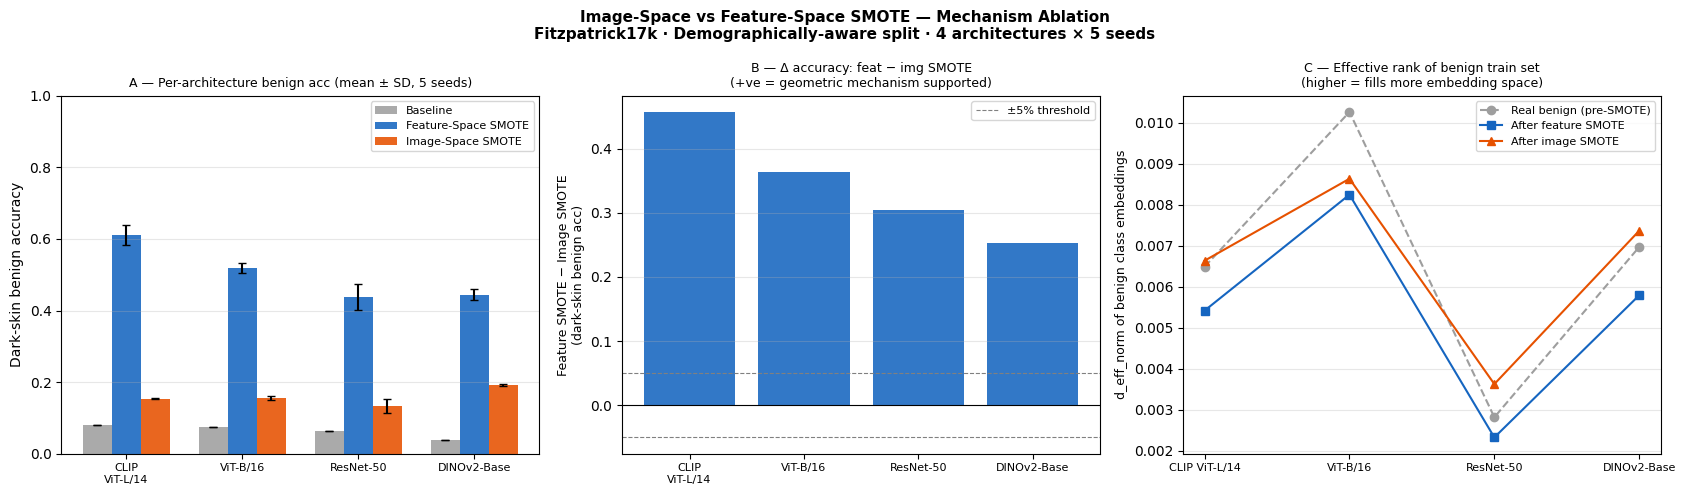

Figure saved: /kaggle/working/nb_smote_ablation.png


In [13]:
# ── CELL 12: Figure ───────────────────────────────────────────

archs = list(df_results['arch'].unique())
x     = np.arange(len(archs))
w     = 0.25
COLORS = {'baseline': '#9E9E9E', 'feature_smote': '#1565C0', 'image_smote': '#E65100'}
LABELS = {'baseline': 'Baseline', 'feature_smote': 'Feature-Space SMOTE', 'image_smote': 'Image-Space SMOTE'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    'Image-Space vs Feature-Space SMOTE — Mechanism Ablation\n'
    'Fitzpatrick17k · Demographically-aware split · 4 architectures × 5 seeds',
    fontsize=11, fontweight='bold')

# Panel A: Dark-skin benign accuracy per architecture
ax = axes[0]
for i, cond in enumerate(CONDITIONS):
    means = [df_summary[(df_summary['arch']==a) & (df_summary['condition']==cond)]['benign_acc_mean'].values[0]
             if len(df_summary[(df_summary['arch']==a) & (df_summary['condition']==cond)]) > 0
             else 0 for a in archs]
    stds  = [df_summary[(df_summary['arch']==a) & (df_summary['condition']==cond)]['benign_acc_std'].values[0]
             if len(df_summary[(df_summary['arch']==a) & (df_summary['condition']==cond)]) > 0
             else 0 for a in archs]
    ax.bar(x + i*w, means, w, yerr=stds, capsize=3,
           label=LABELS[cond], color=COLORS[cond], alpha=0.88)

ax.set_xticks(x + w)
ax.set_xticklabels([a.replace(' ', '\n') for a in archs], fontsize=8)
ax.set_ylabel('Dark-skin benign accuracy', fontsize=10)
ax.set_title('A — Per-architecture benign acc (mean ± SD, 5 seeds)', fontsize=9)
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)
ax.yaxis.grid(True, alpha=0.3)

# Panel B: Feature-space SMOTE vs Image-space SMOTE delta per arch
ax = axes[1]
deltas = []
for arch in archs:
    fs  = df_summary[(df_summary['arch']==arch) & (df_summary['condition']=='feature_smote')]['benign_acc_mean'].values
    is_ = df_summary[(df_summary['arch']==arch) & (df_summary['condition']=='image_smote')]['benign_acc_mean'].values
    delta = float(fs[0] - is_[0]) if len(fs) > 0 and len(is_) > 0 else 0.0
    deltas.append(delta)

bar_colors = ['#1565C0' if d >= 0 else '#E65100' for d in deltas]
ax.bar(archs, deltas, color=bar_colors, alpha=0.88)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.05, color='grey', linestyle='--', linewidth=0.8, label='±5% threshold')
ax.axhline(-0.05, color='grey', linestyle='--', linewidth=0.8)
ax.set_xticklabels([a.replace(' ', '\n') for a in archs], fontsize=8)
ax.set_ylabel('Feature SMOTE − Image SMOTE\n(dark-skin benign acc)', fontsize=9)
ax.set_title('B — Δ accuracy: feat − img SMOTE\n(+ve = geometric mechanism supported)', fontsize=9)
ax.legend(fontsize=8)
ax.yaxis.grid(True, alpha=0.3)

# Panel C: d_eff_norm comparison (real vs feat-synth vs img-synth)
ax = axes[2]
deff_real_vals = [df_results[(df_results['arch']==a) & (df_results['condition']=='baseline')]['deff_benign_train'].mean() for a in archs]
deff_fs_vals   = [df_results[(df_results['arch']==a) & (df_results['condition']=='feature_smote')]['deff_synth'].mean() for a in archs]
deff_is_vals   = [df_results[(df_results['arch']==a) & (df_results['condition']=='image_smote')]['deff_synth'].mean() for a in archs]

ax.plot(archs, deff_real_vals, 'o--', color='#9E9E9E', label='Real benign (pre-SMOTE)', linewidth=1.5)
ax.plot(archs, deff_fs_vals,   's-',  color='#1565C0', label='After feature SMOTE', linewidth=1.5)
ax.plot(archs, deff_is_vals,   '^-',  color='#E65100', label='After image SMOTE', linewidth=1.5)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_ylabel('d_eff_norm of benign class embeddings', fontsize=9)
ax.set_title('C — Effective rank of benign train set\n(higher = fills more embedding space)', fontsize=9)
ax.legend(fontsize=8)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/nb_smote_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: /kaggle/working/nb_smote_ablation.png")

In [14]:
# ── CELL 13: Save outputs ─────────────────────────────────────

df_results.to_csv('/kaggle/working/nb_smote_ablation_full.csv', index=False)
df_summary.to_csv('/kaggle/working/nb_smote_ablation_summary.csv', index=False)

# Cross-arch means
cross_arch = {}
for cond in CONDITIONS:
    sub = df_results[df_results['condition'] == cond]
    cross_arch[cond] = {
        'benign_acc_mean': float(sub['benign_acc'].mean()),
        'benign_acc_std':  float(sub['benign_acc'].std()),
        'demo_auc_mean':   float(sub['demo_auc'].mean()),
    }

# Mechanism verdict
feat_mean = cross_arch['feature_smote']['benign_acc_mean']
img_mean  = cross_arch['image_smote']['benign_acc_mean']
delta_cross = feat_mean - img_mean
if delta_cross > 0.05:
    verdict = 'geometric_mechanism_supported'
elif abs(delta_cross) <= 0.05:
    verdict = 'equivalent_data_quantity_sufficient'
else:
    verdict = 'image_smote_superior_mechanism_unclear'

out = {
    'experiment': 'image_vs_feature_smote_ablation',
    'dataset': 'Fitzpatrick17k',
    'split': 'demographically_aware (train FST I-II, test FST V-VI)',
    'architectures': list(df_results['arch'].unique()),
    'seeds': SEEDS,
    'smote_k_neighbors': SMOTE_K,
    'cross_arch_results': cross_arch,
    'feat_vs_img_delta': float(delta_cross),
    'mechanism_verdict': verdict,
}
with open('/kaggle/working/nb_smote_ablation_summary.json', 'w') as f:
    json.dump(out, f, indent=2)

print("Outputs saved to /kaggle/working/")
print("  nb_smote_ablation.png")
print("  nb_smote_ablation_full.csv")
print("  nb_smote_ablation_summary.csv")
print("  nb_smote_ablation_summary.json")
print()
print(json.dumps(out, indent=2))
print()
print("Paste ALL output + upload PNG to Claude.")

Outputs saved to /kaggle/working/
  nb_smote_ablation.png
  nb_smote_ablation_full.csv
  nb_smote_ablation_summary.csv
  nb_smote_ablation_summary.json

{
  "experiment": "image_vs_feature_smote_ablation",
  "dataset": "Fitzpatrick17k",
  "split": "demographically_aware (train FST I-II, test FST V-VI)",
  "architectures": [
    "CLIP ViT-L/14",
    "ViT-B/16",
    "ResNet-50",
    "DINOv2-Base"
  ],
  "seeds": [
    42,
    0,
    1,
    7,
    99
  ],
  "smote_k_neighbors": 5,
  "cross_arch_results": {
    "baseline": {
      "benign_acc_mean": 0.06403940886699507,
      "benign_acc_std": 0.015577722463883644,
      "demo_auc_mean": 0.7087863730754987
    },
    "feature_smote": {
      "benign_acc_mean": 0.5029556650246307,
      "benign_acc_std": 0.07514960622658262,
      "demo_auc_mean": 0.6980294458978022
    },
    "image_smote": {
      "benign_acc_mean": 0.15837438423645323,
      "benign_acc_std": 0.023285822583826655,
      "demo_auc_mean": 0.7159082912900807
    }
  },
  "f